In [2]:
import pandas as pd
import numpy as np

# 1. Try reading with index_col=0. 
# If the first row is a header and is missing one entry (common in bioinformatics),
# index_col=0 often fixes the 'Expected X, saw Y' alignment issue.
try:
    df = pd.read_csv("tsne.txt", sep='\s+', index_col=0, header=None)
except Exception as e:
    print(f"Standard load failed: {e}")
    # 2. Fallback: Skip the first row if it's a malformed header
    df = pd.read_csv("tsne.txt", sep='\s+', index_col=0, skiprows=1, header=None)

# Extract numeric data
data = df.values.astype(float)
labels = df.index.values

print(f"Success! Data Shape: {data.shape}")
print(f"Number of Features: {data.shape[1]}")

# --- Proceed with Q1 Log Transformation ---
# Add epsilon to handle 0s before log
data_log = np.log(data + 1e-9)

# --- Q2: Squared Distance Matrix ---
def compute_squared_distances(X):
    sum_X = np.sum(np.square(X), axis=1)
    # ||u-v||^2 = ||u||^2 + ||v||^2 - 2u.v
    dist_sq = np.add(np.add(-2 * np.dot(X, X.T), sum_X).T, sum_X)
    return np.maximum(dist_sq, 0)

D_sq = compute_squared_distances(data_log)
print("D_sq computed successfully.")

Standard load failed: Error tokenizing data. C error: Expected 558 fields in line 2, saw 559

Success! Data Shape: (716, 558)
Number of Features: 558
D_sq computed successfully.


In [3]:
# Q3: Probability pj|i and Perplexity
def get_probs_and_perplexity(d_row, sigma):
    # Pj|i = exp(-||xi-xj||^2 / 2*sigma^2) / sum(exp(...))
    p = np.exp(-d_row / (2 * (sigma**2)))
    p[np.isnan(p)] = 0
    sum_p = np.sum(p)
    if sum_p == 0:
        return np.zeros_like(d_row), 0
    p /= sum_p
    
    # Perplexity = 2^H, where H is Shannon Entropy
    entropy = -np.sum(p * np.log2(p + 1e-12))
    return p, 2**entropy

# Q4 & Q5: Binary Search for Sigma
def find_sigmas(D_sq, target_perplexity=30.0):
    n = D_sq.shape[0]
    sigmas = np.zeros(n)
    P = np.zeros((n, n))
    
    for i in range(n):
        low, high = 1e-5, 100.0
        d_row = np.delete(D_sq[i], i) # Ignore self-distance
        
        for _ in range(50): # Binary search iterations
            mid = (low + high) / 2
            p_row, perp = get_probs_and_perplexity(d_row, mid)
            
            if perp > target_perplexity:
                high = mid
            else:
                low = mid
        
        sigmas[i] = mid
        # Re-insert 0 for the diagonal
        row_full = np.zeros(n)
        indices = np.delete(np.arange(n), i)
        row_full[indices] = p_row
        P[i] = row_full
        
    print(f"Mean Sigma: {np.mean(sigmas)}")
    return P

P_matrix = find_sigmas(D_sq, 30.0)

Mean Sigma: 30.722003913291996


In [4]:
# Q6: Symmetric Pij
P_joint = (P_matrix + P_matrix.T) / (2 * P_matrix.shape[0])
P_joint = np.maximum(P_joint, 1e-12)

# Q7: Low-dimensional Q distribution (Student t-distribution)
def compute_q_dist(Y):
    dist_sq = compute_squared_distances(Y)
    inv_dist = 1 / (1 + dist_sq)
    np.fill_diagonal(inv_dist, 0)
    return inv_dist / np.sum(inv_dist)

# Q8: KL Divergence and Gradient
def kl_gradient(P, Q, Y):
    n = Y.shape[0]
    grad = np.zeros_like(Y)
    dist_sq = compute_squared_distances(Y)
    inv_dist = 1 / (1 + dist_sq)
    
    for i in range(n):
        diff = Y[i] - Y
        # (Pij - Qij) * (1 + ||yi-yj||^2)^-1 * (yi-yj)
        mult = (P[i] - Q[i]) * inv_dist[i]
        grad[i] = 4 * np.dot(mult, diff)
    return grad

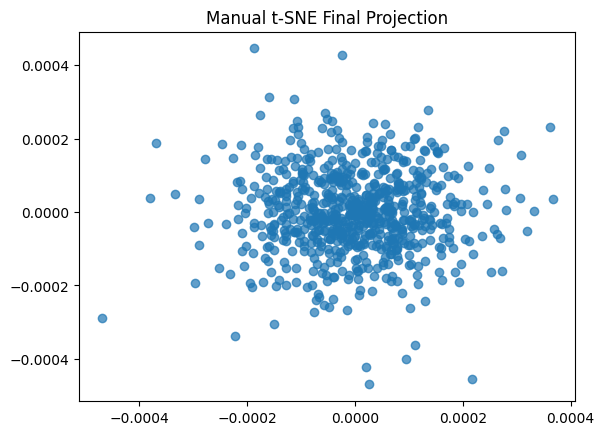

In [6]:
import matplotlib.pyplot as plt
# Q9 & Q10: Gradient Descent
def perform_tsne(P, iterations=200, lr=0.6):
    n = P.shape[0]
    Y = np.random.randn(n, 2) * 1e-4 # Initialize small random values
    
    history = []
    for i in range(iterations):
        Q = compute_q_dist(Y)
        grad = kl_gradient(P, Q, Y)
        Y -= lr * grad
        
        if i % 10 == 0 or i == iterations - 1:
            history.append(Y.copy())
            
    return Y, history

Y_final, history = perform_tsne(P_joint)

# Q10: Final Plot
plt.scatter(Y_final[:, 0], Y_final[:, 1], alpha=0.7)
plt.title("Manual t-SNE Final Projection")
plt.show()

/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


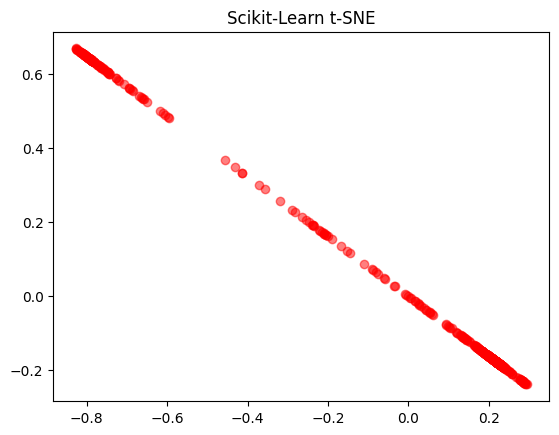

In [9]:

from sklearn.manifold import TSNE


sk_tsne = TSNE(n_components=2, perplexity=30, learning_rate=0.6, n_iter=250, init='random')
Y_sk = sk_tsne.fit_transform(data_log)

plt.scatter(Y_sk[:, 0], Y_sk[:, 1], c='red', alpha=0.5)
plt.title("Scikit-Learn t-SNE")
plt.show()